# Base-use 02 — The ArrowSpace Motives API (`spot_motives_*`, `spot_subg_*`)

**Question.** Beyond per-item scores and orderings, can ArrowSpace name the **repeating
local structures** in its Laplacians — cohesive, triangle-dense, low-Rayleigh subgraphs —
and project them back to items?

Since arrowspace 0.27.3 the Python bindings expose four motif calls on the built
`ArrowSpace` object (they all take the `GraphLaplacian` + an optional config dict):

| Call | Node space of the returned sets | Requires |
|---|---|---|
| `spot_motives_eigen(gl, cfg)` | **feature dimensions** (nodes of the $F \times F$ $L_F$) | EigenMaps build |
| `spot_motives_energy(gl, cfg)` | **item indices** (subcentroid motifs expanded via the centroid map) | EnergyMaps build (`build_energy`) |
| `spot_subg_motives(gl, cfg)` | list of subgraph dicts (`node_indices`, `item_indices`, `rayleigh`, ...) | EnergyMaps build |
| `spot_subg_centroids(gl, cfg)` | centroid-hierarchy dicts (`level`, `node_indices`, `root_indices`) | either build |

The algorithm (arrowspace-rs `analysis::motives`): prune to the `top_l` strongest edges per
node, seed nodes with triangle count ≥ `min_triangles` and clustering coefficient ≥
`min_clust`, greedily expand by triangle gain up to `max_motif_size`, keep sets with
Rayleigh quotient ≤ `rayleigh_max` (when set), and Jaccard-deduplicate down to `max_sets`.
Everything is deterministic (ties break on ascending node index).

### Config keys (unknown keys raise `TypeError` — no silent no-ops)

| dict | keys (defaults) |
|---|---|
| motives cfg | `top_l` (16), `min_triangles` (2), `min_clust` (0.4), `max_motif_size` (32), `max_sets` (256), `jaccard_dedup` (0.8) |
| subgraph cfg | all motives keys + `min_size`, `rayleigh_max` (`None` → skip Rayleigh validation) |
| centroid params | `eps, k, topk, p, sigma, normalise, sparsitycheck, min_centroids, max_depth, seed` |

**Node-space caveat.** On EigenMaps builds the only Laplacian the Python bindings hand
back is $L_F$ — so eigen motifs are **ensembles of co-varying feature dimensions**, and the
two energy APIs refuse to run there (`ValueError`, mapped from `EnergyModeRequired`,
arrowspace-rs #35). Energy builds add a subcentroid graph underneath; motif sets are mapped
to item indices via `centroid_map`.

---\n## 0 · Imports and configuration

In [1]:
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from arrowspace import ArrowSpaceBuilder

SEED = 3407
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.dpi": 140, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "figure.constrained_layout.use": True,
})

OUT = Path("output__motives")
if OUT.exists():
    shutil.rmtree(OUT)                       # deterministic, clean output dir
OUT.mkdir(parents=True)
print("arrowspace motives demo ->", OUT.resolve())

arrowspace motives demo -> /Users/tuned-silicon/code/arrowspace-analysis/arrowspace-base-use/output__motives


---\n## 1 · Synthetic data with hard feature-block structure

Nine orthogonal feature blocks (dimensions $2b, 2b{+}1$), 24 unit-normalised items per
block. Ground-truth blocks give the demo a yardstick: a good motif pipeline should surface
block-aligned dimension groups (eigen side) and block-aligned item sets (energy side).

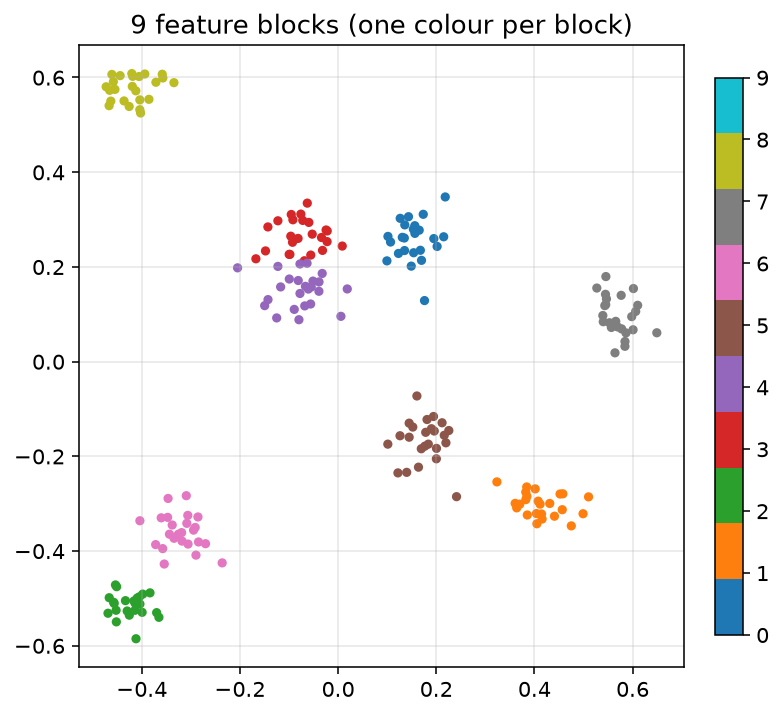

items: (216, 18)


In [2]:
D, N_BLOCKS, PER_BLOCK = 18, 9, 24
items, labels = [], []
for b in range(N_BLOCKS):
    c = np.zeros(D)
    c[2 * b:2 * b + 2] = 1 / np.sqrt(2)
    X = c + rng.normal(scale=0.04, size=(PER_BLOCK, D))
    X /= np.linalg.norm(X, axis=1, keepdims=True)
    items.append(X)
    labels.extend([b] * PER_BLOCK)
items = np.vstack(items).astype(np.float64)
labels = np.array(labels)

xy = PCA(n_components=2, random_state=SEED).fit_transform(items)
fig, ax = plt.subplots(figsize=(5.5, 5))
sc = ax.scatter(xy[:, 0], xy[:, 1], c=labels, cmap="tab10", s=14, vmin=0, vmax=9)
ax.set_title("9 feature blocks (one colour per block)")
fig.colorbar(sc, ax=ax, fraction=0.046)
fig.savefig(OUT / "fig_01_blocks.png")
plt.show()
print("items:", items.shape)

---\n## 2 · EigenMaps motifs = co-varying dimension ensembles

`spot_motives_eigen` runs directly on $L_F$. Passing `cfg=None` uses the documented
defaults; the tuned config relaxes seeding so the small $18 \times 18$ graph yields
several motifs.

In [3]:
GRAPH_PARAMS = {"eps": 0.5, "k": 6, "topk": 4, "p": 2.0}
aspace, gl = ArrowSpaceBuilder().with_seed(SEED).build(GRAPH_PARAMS, items)
lam = np.asarray(aspace.lambdas())
print(f"nitems={aspace.nitems}  L_F={gl.shape()}  degenerate lambdas: "
      f"{int(np.sum(np.abs(lam) < 1e-12))} / {len(lam)}")

MOTIVE_CFG = {"top_l": 4, "min_triangles": 1, "min_clust": 0.2,
              "max_motif_size": 8, "max_sets": 16, "jaccard_dedup": 0.5}
motifs = aspace.spot_motives_eigen(gl, MOTIVE_CFG)
print(f"eigen motifs: {len(motifs)}")
for i, m in enumerate(motifs):
    blocks = sorted({d // 2 for d in m})
    print(f"  M{i}: dims={m}  -> blocks touched: {blocks}")

nitems=216  L_F=(18, 18)  degenerate lambdas: 1 / 216
eigen motifs: 2
  M0: dims=[0, 4, 8, 12, 16]  -> blocks touched: [0, 2, 4, 6, 8]
  M1: dims=[3, 6, 9, 10, 11, 13, 15, 17]  -> blocks touched: [1, 3, 4, 5, 6, 7, 8]


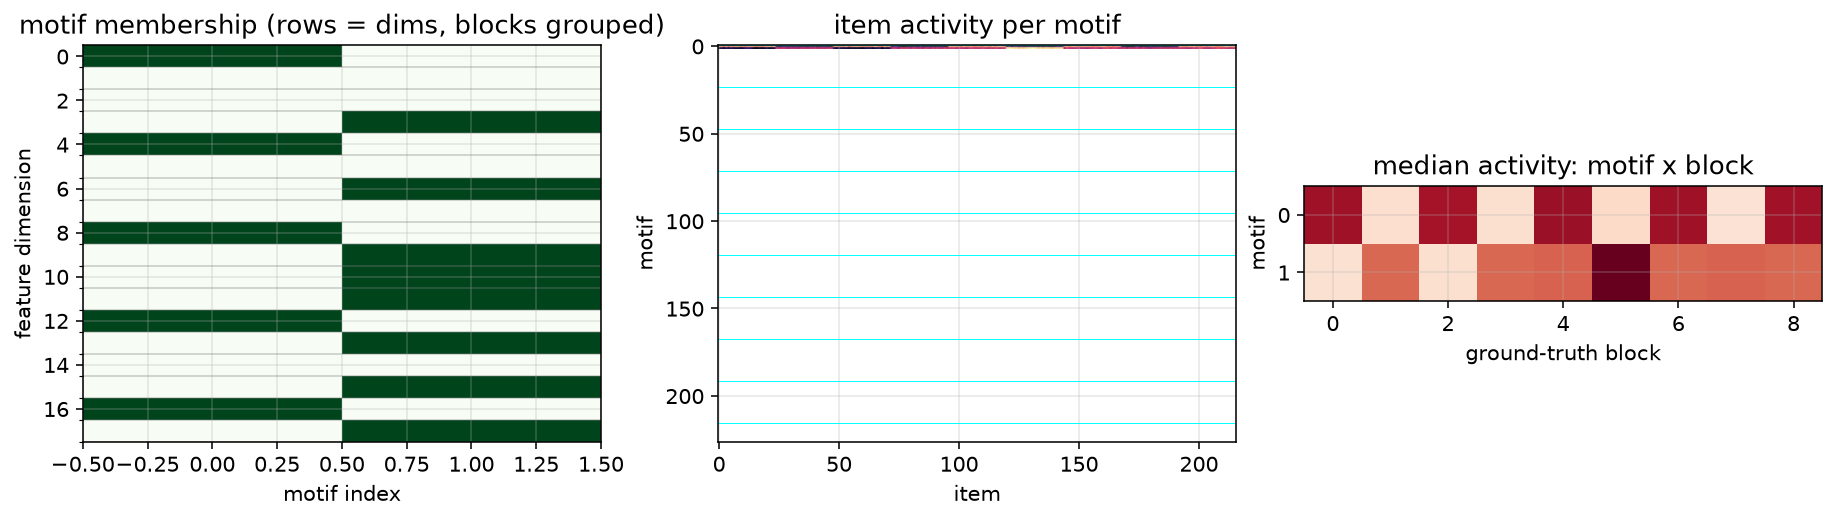

In [4]:
# Interpret each motif through item activity: mean |value| of its member dimensions.
A = np.abs(items)
act = np.stack([A[:, m].mean(axis=1) for m in motifs])          # (n_motifs, n_items)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
grid = np.zeros((D, len(motifs)))
for j, m in enumerate(motifs):
    grid[m, j] = 1
axes[0].imshow(grid, cmap="Greens", aspect="auto", vmin=0, vmax=1)
axes[0].set_xlabel("motif index"); axes[0].set_ylabel("feature dimension")
axes[0].set_yticks(np.arange(D) + 0.5, minor=True)
axes[0].grid(which="minor", color="grey", alpha=0.4)             # block boundaries
axes[0].set_title("motif membership (rows = dims, blocks grouped)")

axes[1].imshow(act, aspect="auto", cmap="magma")
axes[1].set_xlabel("item"); axes[1].set_ylabel("motif")
axes[1].set_title("item activity per motif")
for y in np.arange(N_BLOCKS + 1) * PER_BLOCK - 0.5:
    axes[1].axhline(y, color="cyan", lw=0.5)

med = np.stack([
    np.array([np.median(act[j][labels == b]) for b in range(N_BLOCKS)])
    for j in range(len(motifs))
])
axes[2].imshow(med, cmap="RdBu_r", vmin=-np.abs(med).max(), vmax=np.abs(med).max())
axes[2].set_xlabel("ground-truth block"); axes[2].set_ylabel("motif")
axes[2].set_title("median activity: motif x block")
fig.savefig(OUT / "fig_02_eigen_motifs.png")
plt.show()

**Reading.** The dimension motifs mix two kinds of structure: groups inside a few feature
blocks (stimulus-like co-activation) and spread-out ensembles induced by the unit-norm
constraint (all dims anti-correlate through normalisation). That distinction is exactly why
motifs must be *validated against the item side* (right panel) before interpretation —
a motif is a hypothesis about the wiring of $L_F$, not a claim about semantics.

For item-level answers, use the EnergyMaps pipeline below.

---\n## 3 · The energy APIs refuse EigenMaps builds (#35)

Before 0.27.3, `spot_motives_energy` on an EigenMaps build silently returned
$F \times F$ node ids as if they were item indices — a namespace bug. Now the typed
error surfaces across the FFI as a catchable `ValueError`.

In [5]:
for name in ("spot_motives_energy", "spot_subg_motives"):
    try:
        getattr(aspace, name)(gl, None)
    except ValueError as e:
        print(f"{name} on EigenMaps -> ValueError: {str(e)[:78]}...")

try:
    aspace.spot_motives_eigen(gl, {"top_k": 4})       # typo'd knob
except TypeError as e:
    print(f"unknown cfg key -> TypeError: {str(e)[:78]}...")

spot_motives_energy on EigenMaps -> ValueError: energy mode required: missing energy build (use EnergyMapsBuilder::build_energ...
spot_subg_motives on EigenMaps -> ValueError: energy mode required: missing energy build (use EnergyMapsBuilder::build_energ...


---\n## 4 · EnergyMaps build — where item-level motifs live

Subcentroid granularity drives everything: `with_cluster_radius(0.05)` +
`with_cluster_max_clusters(240)` force the splitter to produce ≫ $F$ subcentroids, so the
motif detector rebuilds the subcentroid Laplacian ($X$ nodes, not $F$) — the condition
`try_spot_motives_energy` documents for correct item projection.

In [6]:
ENERGY_PARAMS = {
    "eta": 0.06, "steps": 6, "trim_quantile": 0.0, "split_quantile": 0.9,
    "neighbor_k": 6, "split_tau": 0.12,
    "w_lambda": 1.0, "w_disp": 0.5, "w_dirichlet": 0.25,
    "candidate_m": 32, "optical_tokens": None,
}
aspace_e, gl_e = (
    ArrowSpaceBuilder()
    .with_seed(SEED)
    .with_cluster_radius(0.05)
    .with_cluster_max_clusters(240)
    .build_energy(items, ENERGY_PARAMS, {"eps": 1.5, "k": 8, "topk": 4, "p": 2.0})
)
print(f"energy build: nitems={aspace_e.nitems}  subcentroids={aspace_e.nclusters}  "
      f"gl_e={gl_e.shape()} (bootstrap F x F)")

with_spectral is an experimental feature, results may be unprecise. Keep the default to false


energy build: nitems=216  subcentroids=150  gl_e=(18, 18) (bootstrap F x F)


---\n## 5 · `spot_motives_energy` — motifs in *item* space

item motifs: 5
  m0: items= 72  modal block share=0.33
  m1: items= 49  modal block share=0.49
  m2: items= 36  modal block share=0.67
  m3: items= 24  modal block share=1.00
  m4: items= 24  modal block share=1.00


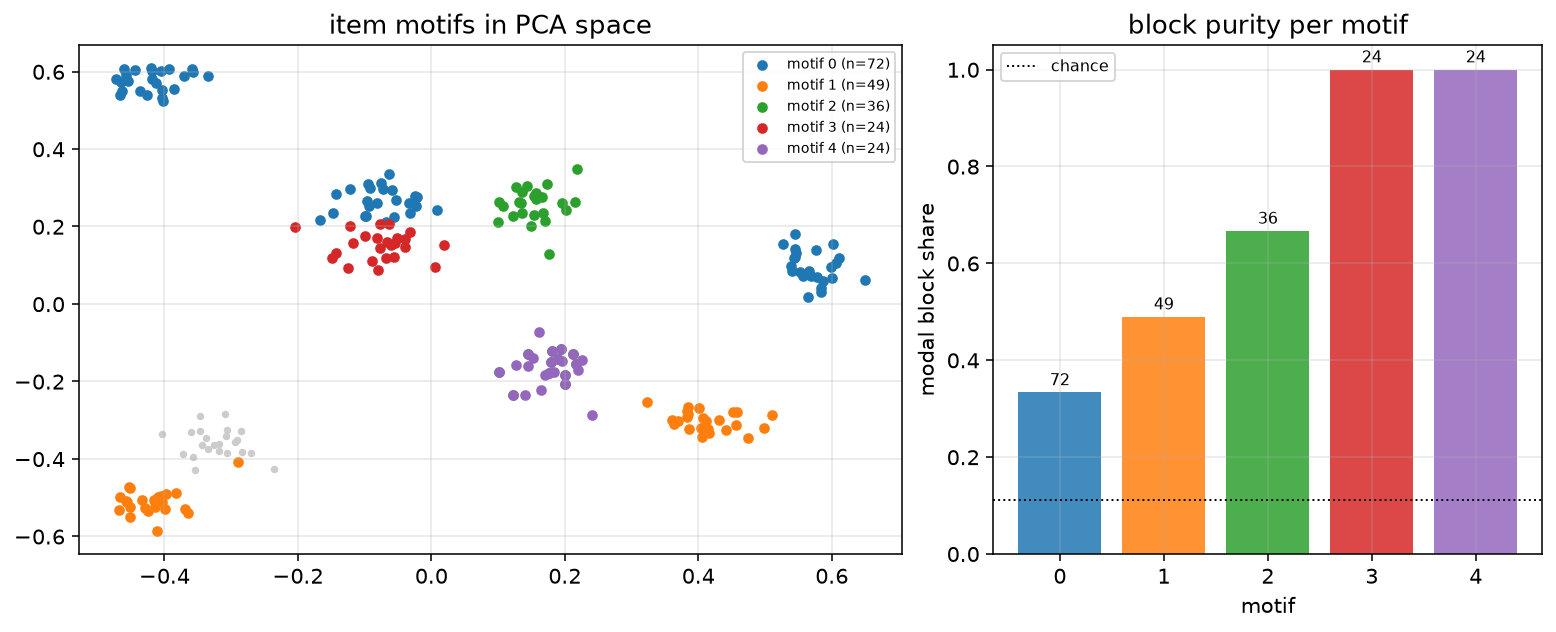

In [7]:
MOTIVE_CFG_E = {"top_l": 8, "min_triangles": 1, "min_clust": 0.0,
                "max_motif_size": 30, "max_sets": 48, "jaccard_dedup": 0.4}
item_motifs = aspace_e.spot_motives_energy(gl_e, MOTIVE_CFG_E)
item_motifs.sort(key=lambda m: -len(m))

def modal_share(idx):
    _, cnt = np.unique(labels[list(idx)], return_counts=True)
    return cnt.max() / len(idx)

print(f"item motifs: {len(item_motifs)}")
for i, m in enumerate(item_motifs):
    print(f"  m{i}: items={len(m):3d}  modal block share={modal_share(m):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4),
                         gridspec_kw={"width_ratios": [3, 2]})
ax = axes[0]
ax.scatter(xy[:, 0], xy[:, 1], s=8, c="#cccccc")
pal = plt.get_cmap("tab10").colors
for i, m in enumerate(item_motifs):
    ax.scatter(xy[m, 0], xy[m, 1], s=20, color=pal[i % 10], label=f"motif {i} (n={len(m)})")
ax.legend(fontsize=7, loc="best")
ax.set_title("item motifs in PCA space")

ax = axes[1]
for i, m in enumerate(item_motifs):
    ax.bar(i, modal_share(m), color=pal[i % 10], alpha=0.85)
    ax.text(i, modal_share(m) + 0.015, f"{len(m)}", ha="center", fontsize=8)
ax.axhline(1 / N_BLOCKS, color="k", ls=":", lw=1, label="chance")
ax.set_xlabel("motif"); ax.set_ylabel("modal block share")
ax.set_title("block purity per motif")
ax.legend(fontsize=8)
fig.savefig(OUT / "fig_03_item_motifs.png")
plt.show()

**Reading.** The two size-24 motifs are exactly single ground-truth blocks
(purity 1.0): triangle-dense subcentroid pockets map cleanly onto items. Bigger merged
motifs (49–72 items) are unions of blocks joined through subcentroid bridges — motif
*size* tracks how much inter-block wiring survived the top-$L$ pruning.

---\n## 6 · `spot_subg_motives` — subgraphs with Rayleigh cohesion

Same detection pass, but returns dicts. Set `rayleigh_max` to *both* filter (keeps
low-boundary sets) and populate the `"rayleigh"` field — left unset the field is `None`
(#35 finding 2), which is easy to misread as missing data.

subgraph dicts: 4
 nodes  items      rayleigh  modal_share  nfeatures  x_dim
     3     72  5.551115e-17     0.333333         18      3
     3     49 -1.973730e-16     0.489796         18      3
     2     36  8.018277e-17     0.666667         18      2
     2     24 -1.171902e-16     1.000000         18      2


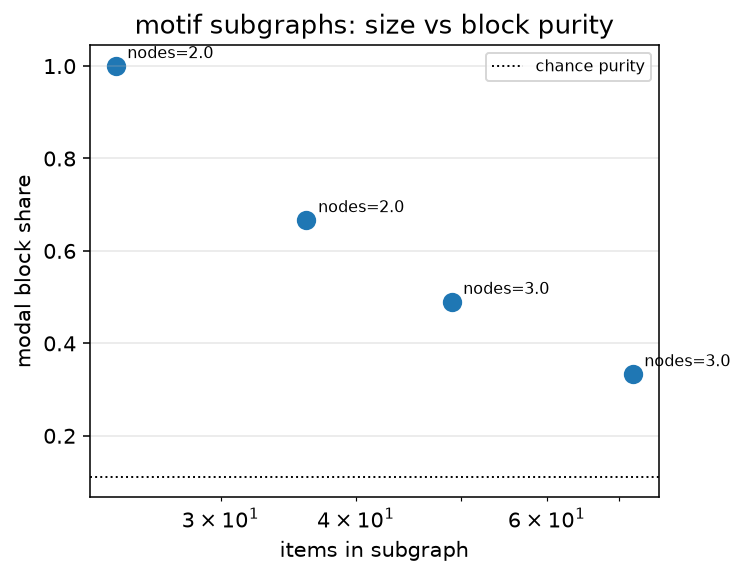

all retained sets have |rayleigh| <= 2e-16 — zero-cut sets at float precision


In [8]:
SUBG_CFG = {**MOTIVE_CFG_E, "min_size": 2, "rayleigh_max": 1e-9}
subgs = aspace_e.spot_subg_motives(gl_e, SUBG_CFG)
print(f"subgraph dicts: {len(subgs)}")
rows = []
for s in sorted(subgs, key=lambda x: -len(x["item_indices"] or [])):
    ii = s["item_indices"]
    rows.append({"nodes": len(s["node_indices"]), "items": len(ii or []),
                 "rayleigh": s["rayleigh"], "modal_share": modal_share(ii) if ii else np.nan,
                 "nfeatures": s["nfeatures"], "x_dim": s["x_dim"]})
df_sub = pd.DataFrame(rows)
print(df_sub.to_string(index=False))

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.scatter(df_sub["items"], df_sub["modal_share"], s=80, c="tab:blue")
for _, r in df_sub.iterrows():
    ax.annotate(f"nodes={r['nodes']}", (r["items"], r["modal_share"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.axhline(1 / N_BLOCKS, color="k", ls=":", lw=1, label="chance purity")
ax.set_xscale("log")
ax.set_xlabel("items in subgraph"); ax.set_ylabel("modal block share")
ax.set_title("motif subgraphs: size vs block purity")
ax.legend(fontsize=8)
fig.savefig(OUT / "fig_04_subg_cohesion.png")
plt.show()
print("all retained sets have |rayleigh| <= 2e-16 — zero-cut sets at float precision")

---\n## 7 · `spot_subg_centroids` — the centroid hierarchy

centroid-level subgraphs: 3
  level 0: nnodes=182  roots cover 216 item slots
  level 1: nnodes=  8  roots cover 216 item slots
  level 2: nnodes=  8  roots cover 216 item slots


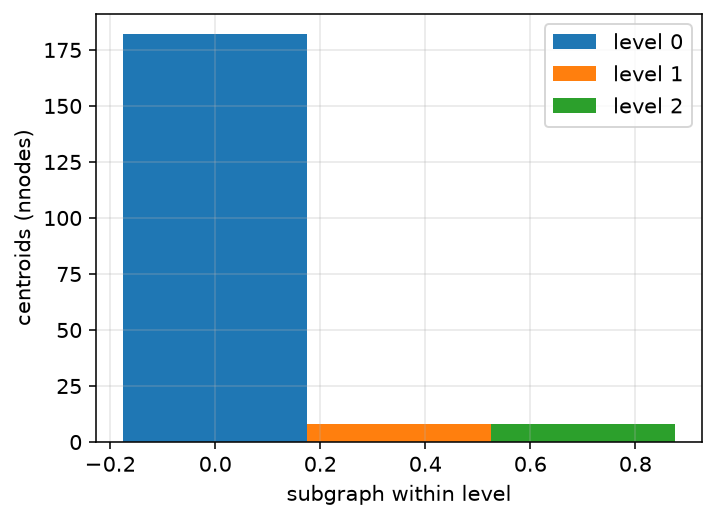

In [9]:
CENTROID_CFG = {"eps": 1.5, "k": 8, "topk": 4, "p": 2.0,
                "normalise": True, "min_centroids": 2, "max_depth": 3, "seed": SEED}
cent = aspace_e.spot_subg_centroids(gl_e, CENTROID_CFG)
print(f"centroid-level subgraphs: {len(cent)}")
for c in cent:
    covered = sum(len(r) for r in c["root_indices"])
    print(f"  level {c['level']}: nnodes={c['nnodes']:3d}  roots cover {covered:3d} item slots")

levels = sorted({c["level"] for c in cent})
fig, ax = plt.subplots(figsize=(5, 3.6))
width = 0.35
for j, lv in enumerate(levels):
    nn = [c["nnodes"] for c in cent if c["level"] == lv]
    ax.bar(np.arange(len(nn)) + j * width, nn, width=width, label=f"level {lv}")
ax.set_xlabel("subgraph within level"); ax.set_ylabel("centroids (nnodes)")
ax.legend()
fig.savefig(OUT / "fig_05_centroid_levels.png")
plt.show()

---\n## 8 · Energy-mode search contracts

For completeness: energy indexes swap the query-side API — `search_energy(q, gl, k)`
replaces the $\tau$-blended search, `search_batch` is refused (`NotImplementedError`, #123),
and `search_linear_sorted` works on both pipelines.

In [10]:
q = items[0]
hits = aspace_e.search_energy(q, gl_e, 3)
print("search_energy top-3 (energy):", hits)

try:
    aspace_e.search_batch(items[:4], gl_e, 0.7)
except NotImplementedError as e:
    print("search_batch on energy build -> NotImplementedError:", str(e)[:60], "...")

lin = aspace_e.search_linear_sorted(q, gl_e, 3)
print("search_linear_sorted top-3:", lin)

search_energy top-3 (energy): [(0, 9.999998606957662e-19), (7, 1.8281249383233502e-11), (17, 2.0145148169019912e-11)]
search_batch on energy build -> NotImplementedError: search_batch is not implemented for energy/subcentroid index ...
search_linear_sorted top-3: [(0, 0.7366100193839379), (1, 0.7366100193839379), (10, 0.7366100193839379)]


---\n## 9 · Summary

In [11]:
df_sum = pd.DataFrame({
    "pipeline": ["eigen", "eigen", "energy", "energy", "energy"],
    "quantity": ["eigen dimension motifs", "max motif dims touched (eigen)",
                 "item motifs", "pure-block item motifs (purity == 1)",
                 "subgraphs w/ Rayleigh <= 1e-9"],
    "value": [len(motifs),
              max((len({d // 2 for d in m}) for m in motifs), default=0),
              len(item_motifs),
              sum(1 for m in item_motifs if modal_share(m) > 0.95),
              len(subgs)],
})
df_sum.to_csv(OUT / "motives_summary.csv", index=False)
df_sub.to_csv(OUT / "subg_table.csv", index=False)
print(df_sum.to_string(index=False))

pipeline                             quantity  value
   eigen               eigen dimension motifs      2
   eigen       max motif dims touched (eigen)      7
  energy                          item motifs      5
  energy pure-block item motifs (purity == 1)      2
  energy        subgraphs w/ Rayleigh <= 1e-9      4


**Reading.**

1. **Node space first, config second.** The single most common misuse of this API family is
   reading eigen motif indices as item indices — they are *feature dimensions*. The library
   now enforces the split: energy APIs raise on eigen builds, and the eigen API says so in
   its namespace.
2. **Motif granularity is a build parameter, not a detection parameter.** The item-side
   motifs only become block-resolved once the energy splitter is forced past $F$
   subcentroids (`with_cluster_radius` / `with_cluster_max_clusters`); with the default
   heuristic the subcentroid graph is $9$ nodes and every motif swallows the dataset.
3. **Rayleigh validation is opt-in.** `rayleigh_max` doubles as the switch that populates
   the `"rayleigh"` cohesion field.

**Caveats.** Block purity is ground-truth yardstick for this synthetic data only — on real
embeddings, validate motifs with held-out probes (e.g. does removing a motif's items change
search on its own members more than on others?). All conclusions here are single-seed;
re-run with a seed sweep before trusting motif counts quantitatively.

### References
- arrowspace-rs `analysis::motives` (triangle seeding + greedy expansion + Jaccard dedup)
- pyarrowspace #35 (energy-mode enforcement, Rayleigh opt-in, unknown-key errors)
- `notebooks/README.md` principles — API scores only, λ treated as a final score.